# Etapa 4 - Modelagem Preditiva

Nesta etapa são desenvolvidos modelos de aprendizado de máquina para prever a via de transporte utilizada em operações de exportação brasileiras. O objetivo é construir modelos capazes de classificar o modal de transporte a partir das características da carga, da origem da exportação e do destino comercial. Além da capacidade preditiva, também será realizada uma análise de interpretabilidade para identificar quais variáveis exercem maior influência sobre a escolha da via de transporte.

Serão avaliados dois modelos neste notebook:

- **Regressão Logística** (modelo simples e mais interpretável);
- **Random Forest** (modelo mais complexo e capaz de capturar relações não lineares).

Os modelos serão comparados utilizando métricas de desempenho apropriadas para problemas de classificação multiclasse.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## Carregamento da Base de Dados

A base de dados utilizada nesta etapa corresponde ao conjunto tratado e enriquecido durante as etapas anteriores do projeto. Esse conjunto já passou por alguns processos de limpeza, tratamento de inconsistências, integração de dados e engenharia de atributos.

In [2]:
# Carregando o dataset tidy (mesma fonte usada no notebook do LightGBM), com caminho relativo
df = pd.read_parquet('../data/exports_tidy.parquet')

## Análise da Variável Alvo

Antes da construção dos modelos, é importante compreender a distribuição da variável que será prevista. Neste projeto, o objetivo é prever a variável `transport_route`, que representa a via de transporte utilizada na exportação. A análise da distribuição permite identificar possíveis problemas de desbalanceamento entre as classes.

In [3]:
# Distribuição da Variável Alvo
df["transport_route"].value_counts()

transport_route
1     913761
4     466747
7     290955
15     19913
0      16902
12       528
6        411
9        280
3        133
2         86
8         28
13         2
Name: count, dtype: int64

In [4]:
(
    df["transport_route"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

transport_route
1     53.44
4     27.30
7     17.02
15     1.16
0      0.99
12     0.03
6      0.02
9      0.02
3      0.01
2      0.01
8      0.00
13     0.00
Name: proportion, dtype: float64

### Desbalanceamento das Classes

Observa-se que algumas categorias possuem quantidade extremamente reduzida de registros quando comparadas às principais vias de transporte. Esse desbalanceamento pode dificultar o aprendizado dos modelos, levando-os a favorecer as classes majoritárias. Para reduzir esse problema, as classes com baixa representatividade são agrupadas em uma única categoria denominada **Other**.

# Criando o Target

In [5]:
# Agrupamento das Classes (alinhado ao notebook do LightGBM)
# - Remove a classe 0 (VIA NAO DECLARADA): e ausencia de informacao, nao um modal real
# - Mantem 1, 4, 7 e 15 como classes proprias
# - Agrupa a cauda rara restante em "OUTROS"
# Resultado: 5 classes, sobre as mesmas linhas usadas no LightGBM.
main_routes = [1, 4, 7, 15]

route = df["transport_route"].astype(int)
df = df[route != 0].copy()
route = route[route != 0]

df["transport_route_grouped"] = np.where(
    route.isin(main_routes),
    route.astype(str),
    "OUTROS"
)

In [6]:
# Conferência do Novo Target
(
    df["transport_route_grouped"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

transport_route_grouped
1         53.98
4         27.57
7         17.19
15         1.18
OUTROS     0.09
Name: proportion, dtype: float64

In [7]:
# Mapeamento dos codigos de via de transporte para nomes legiveis
# Usado para rotular os eixos das matrizes de confusao com os nomes das classes,
# em vez de exibir apenas os codigos numericos
ROUTE_NAMES = {
    "1": "MARITIMA",
    "4": "AEREA",
    "7": "RODOVIARIA",
    "15": "VICINAL_FRONTEIRICO",
    "OUTROS": "OUTROS"
}

# Ordem fixa das classes, da majoritaria para a minoritaria,
# utilizada em todos os relatorios e matrizes de confusao deste notebook
CLASS_ORDER = ["1", "4", "7", "15", "OUTROS"]
CLASS_LABELS = [ROUTE_NAMES[c] for c in CLASS_ORDER]

# Seleção de Atributos

## Features Numéricas
As variáveis numéricas representam características quantitativas da exportação, como peso líquido, valor FOB (FOB: o preço do produto cobre apenas o custo de fabricação e a entrega até o porto ou local de embarque) e valor por quilograma. Esses atributos fornecem informações relacionadas ao volume físico e ao valor econômico das operações.

Para garantir uma comparação justa entre os modelos avaliados neste trabalho (Regressão Logística e Random Forest) e o modelo LightGBM avaliado em etapa complementar, foi utilizado exatamente o mesmo conjunto de variáveis de entrada em ambos os notebooks.

In [8]:
numeric_features = [
    "net_weight_kg",
    "fob_value_usd",
    "value_per_kg"
]

## Features Categóricas
As variáveis categóricas representam informações geográficas e comerciais, como estado de origem, país de destino, capítulo NCM do produto e mês da operação. Essas informações podem influenciar diretamente a escolha do modal de transporte utilizado na operação.

In [9]:
categorical_features = [
    "origin_state",
    "country_code",
    "ncm_chapter",
    "month",
    "statistical_unit_code_export"
]

## Target
A variável alvo do problema é `transport_route_grouped`, que representa a via de transporte utilizada após o agrupamento das categorias raras. O problema é tratado como uma tarefa de classificação multiclasse supervisionada.

In [10]:
target = "transport_route_grouped"

# Separação - Treino e Teste
Nesta etapa são definidas as variáveis de entrada (features) e a variável que será prevista pelos modelos (target).

In [11]:
X = df[
    numeric_features +
    categorical_features
]

y = df[target]

O conjunto de dados é dividido em duas partes:

- Treino (80%)
- Teste (20%)

A divisão estratificada preserva a proporção das classes em ambos os conjuntos. Essa estratégia permite avaliar o desempenho dos modelos em dados não vistos durante o treinamento, reduzindo o risco de overfitting.

In [12]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(1354275, 8)
(338569, 8)


# Pré-Processamento
Os modelos utilizados exigem que os dados estejam em formato numérico e sem valores ausentes.

Para isso são aplicadas as seguintes transformações:

- Imputação de valores ausentes;
- Padronização das variáveis numéricas;
- Codificação One-Hot das variáveis categóricas.

Todas as transformações são incorporadas ao pipeline de treinamento.

In [13]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

# Modelo 1 - Logistic Regression
A **Regressão Logística** é um algoritmo de classificação supervisionada utilizado como modelo base em problemas de classificação. Trata-se de um classificador capaz de estimar probabilidades para cada classe.

Suas principais vantagens são:

- Simplicidade;
- Baixo custo computacional;
- Facilidade de interpretação.

Por outro lado, o modelo assume relações predominantemente lineares entre as variáveis de entrada e a variável alvo.

In [14]:
logistic_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        )
    )
])

In [15]:
# Treinamento LR
logistic_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [16]:
y_pred_logistic = logistic_pipeline.predict(
    X_test
)

## Avaliação do Modelo

Para avaliar o desempenho serão utilizadas as seguintes métricas:

- **Accuracy:** proporção de classificações corretas;
- **F1 Macro:** média do desempenho entre todas as classes;
- **F1 Weighted:** média ponderada pelo tamanho de cada classe.

A utilização conjunta dessas métricas é importante devido ao desbalanceamento presente na variável alvo.

In [17]:
logistic_accuracy = accuracy_score(
    y_test,
    y_pred_logistic
)

logistic_f1_macro = f1_score(
    y_test,
    y_pred_logistic,
    average="macro"
)

logistic_f1_weighted = f1_score(
    y_test,
    y_pred_logistic,
    average="weighted"
)

print("Accuracy:", logistic_accuracy)
print("F1 Macro:", logistic_f1_macro)
print("F1 Weighted:", logistic_f1_weighted)

Accuracy: 0.7254060472163725
F1 Macro: 0.522577195355837
F1 Weighted: 0.7499630155753481


In [18]:
print(
    classification_report(
        y_test,
        y_pred_logistic
    )
)

              precision    recall  f1-score   support

           1       0.94      0.71      0.81    182752
          15       0.22      0.98      0.36      3983
           4       0.61      0.74      0.67     93349
           7       0.73      0.72      0.73     58191
      OUTROS       0.02      0.87      0.05       294

    accuracy                           0.73    338569
   macro avg       0.50      0.81      0.52    338569
weighted avg       0.80      0.73      0.75    338569



### Análise

O modelo acerta 72,5% das previsões no geral (**Accuracy**), mas o desempenho varia bastante entre as classes.
- A classe **MARITIMA** (1), que é majoritária, tem boa precisão (0,94), enquanto as classes raras como **OUTROS** e **VICINAL_FRONTEIRICO** (15) têm precisão muito baixa, mesmo com recall alto, ou seja, o modelo acerta a maioria dos casos dessas classes, mas também classifica muitos outros casos erroneamente como sendo delas.

## Matriz de Confusão

A matriz de confusão apresenta os acertos e erros do modelo para cada classe. Os valores presentes na diagonal principal representam classificações corretas, enquanto os demais valores representam confusões entre categorias.

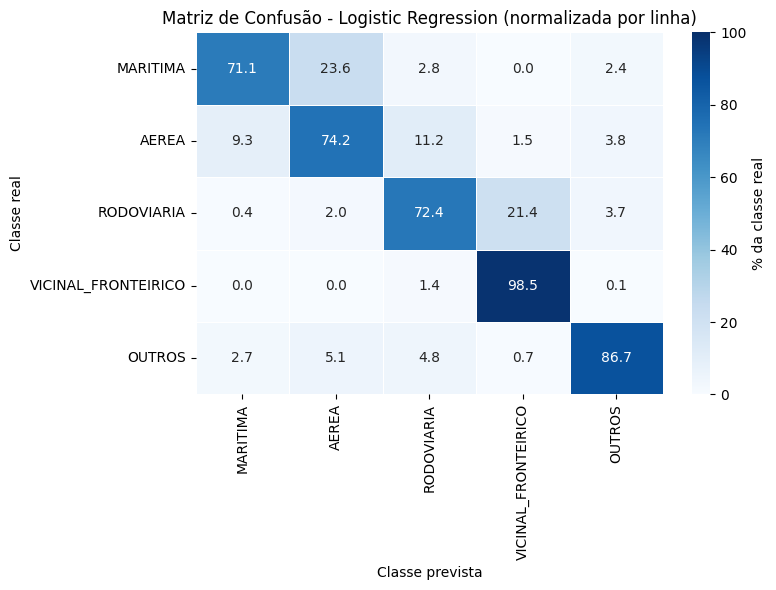

In [19]:
cm = confusion_matrix(
    y_test,
    y_pred_logistic,
    labels=CLASS_ORDER,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% da classe real"},
    ax=ax
)

ax.set_title("Matriz de Confusão - Logistic Regression (normalizada por linha)")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

plt.tight_layout()
plt.show()

A matriz de confusão mostra que o modelo identifica bem as classes **VICINAL_FRONTEIRICO** (recall 0,98) e **OUTROS**, e razoavelmente a **AEREA** e a **RODOVIARIA**. A maior dificuldade está na **MARITIMA**, cujo recall cai para 0,71 porque parte dela acaba prevista como **AEREA**. As classes raras têm recall alto e precisão baixa, ou seja, são bem encontradas, mas superestimadas.

# Modelo 2 - Random Forest
O **Random Forest** é um algoritmo baseado em múltiplas árvores de decisão. Cada árvore aprende padrões diferentes do conjunto de dados e a decisão final é obtida por votação entre todas as árvores.

Entre suas principais vantagens estão:

- Capacidade de capturar relações não lineares;
- Robustez a ruídos;
- Boa performance em bases complexas;
- Possibilidade de analisar importância das variáveis.

Espera-se que o Random Forest apresente desempenho superior à Regressão Logística.

In [20]:
rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=30,
            max_depth=15,
            random_state=42,
            class_weight="balanced",
            n_jobs=-1
        )
    )
])

In [21]:
rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [22]:
y_pred_rf = rf_pipeline.predict(
    X_test
)

## Avaliação do Random Forest
As mesmas métricas utilizadas na Regressão Logística são empregadas aqui para garantir uma comparação justa entre os modelos.

In [23]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_f1_macro = f1_score(
    y_test,
    y_pred_rf,
    average="macro"
)

rf_f1_weighted = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Accuracy:", rf_accuracy)
print("F1 Macro:", rf_f1_macro)
print("F1 Weighted:", rf_f1_weighted)

Accuracy: 0.7464859452578352
F1 Macro: 0.5365755249848875
F1 Weighted: 0.7659401757375067


In [24]:
print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           1       0.93      0.73      0.82    182752
          15       0.21      0.99      0.35      3983
           4       0.63      0.80      0.71     93349
           7       0.76      0.69      0.72     58191
      OUTROS       0.05      0.87      0.09       294

    accuracy                           0.75    338569
   macro avg       0.52      0.82      0.54    338569
weighted avg       0.81      0.75      0.77    338569



### Análise

O **Random Forest** supera a **Regressão Logística** em todas as métricas: **Accuracy** de 72,5% para 74,6% e **F1 Weighted** de 0,75 para 0,77. As classes minoritárias também melhoram um pouco, por exemplo a precisão da classe **OUTROS** sobe de 0,02 para 0,05.

### Matriz de Confusão


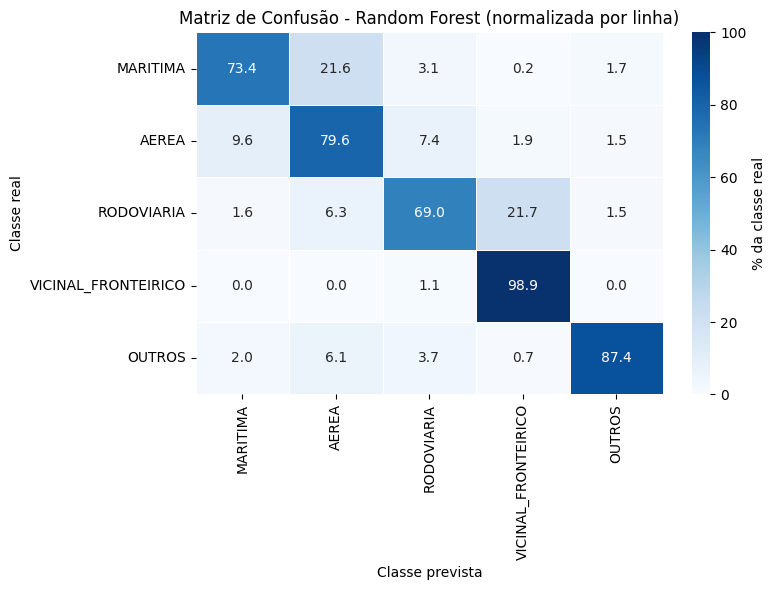

In [25]:
cm = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=CLASS_ORDER,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% da classe real"},
    ax=ax
)

ax.set_title("Matriz de Confusão - Random Forest (normalizada por linha)")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

plt.tight_layout()
plt.show()

A matriz de confusão do Random Forest mostra melhora em relação à Regressão Logística, especialmente na classe **AEREA** (recall 0,80). A classe **VICINAL_FRONTEIRICO** continua sendo muito bem identificada (recall 0,99), mas ainda há confusão envolvendo a **RODOVIARIA**, cujo recall fica em 0,69.

# Otimização de Hiperparâmetros - Random Forest

Após o treinamento inicial do Random Forest, foi realizada uma otimização de hiperparâmetros com Grid Search e validação cruzada, testando o grid abaixo:

- `n_estimators`: [20, 50]
- `max_depth`: [10, 20, None]
- `min_samples_split`: [5]
- `min_samples_leaf`: [2]

A melhor combinação encontrada foi `n_estimators=50`, `max_depth=None`, `min_samples_split=5` e `min_samples_leaf=2`. Como a busca é custosa (mais de uma hora nesta base), o modelo final é retunado diretamente com esses parâmetros, sem refazer a busca a cada execução.

In [26]:
# Melhores hiperparametros encontrados pelo Grid Search (cv, scoring=f1_weighted)
best_params = {
    "n_estimators": 50,
    "max_depth": None,
    "min_samples_split": 5,
    "min_samples_leaf": 2,
}

In [27]:
# Modelo final retunado diretamente com os melhores parametros (sem refazer a busca)
best_rf = Pipeline([
    ("preprocessor", preprocessor),
    (
        "classifier",
        RandomForestClassifier(
            **best_params,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
    )
])

## Busca dos Melhores Parâmetros

O Grid Search avalia diferentes combinações de hiperparâmetros por meio de validação cruzada. Essa abordagem reduz a dependência de uma única divisão treino/teste e aumenta a confiabilidade da seleção do modelo.

In [28]:
best_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

## Avaliação do Modelo Otimizado
Após identificar a melhor configuração, o modelo é novamente avaliado utilizando o conjunto de teste. Os resultados serão comparados com os modelos anteriores para verificar se houve ganho de desempenho.

In [29]:
print(best_params)

{'n_estimators': 50, 'max_depth': None, 'min_samples_split': 5, 'min_samples_leaf': 2}


In [30]:
y_pred_best_rf = best_rf.predict(
    X_test
)

In [31]:
best_rf_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

best_rf_f1_macro = f1_score(
    y_test,
    y_pred_best_rf,
    average="macro"
)

best_rf_f1_weighted = f1_score(
    y_test,
    y_pred_best_rf,
    average="weighted"
)

print("Accuracy:", best_rf_accuracy)
print("F1 Macro:", best_rf_f1_macro)
print("F1 Weighted:", best_rf_f1_weighted)

Accuracy: 0.8317625063133364
F1 Macro: 0.6749471299964553
F1 Weighted: 0.8395429324733746


In [32]:
print(
    classification_report(
        y_test,
        y_pred_best_rf
    )
)

              precision    recall  f1-score   support

           1       0.97      0.81      0.88    182752
          15       0.33      0.93      0.48      3983
           4       0.72      0.85      0.78     93349
           7       0.80      0.84      0.82     58191
      OUTROS       0.27      0.80      0.40       294

    accuracy                           0.83    338569
   macro avg       0.62      0.85      0.67    338569
weighted avg       0.86      0.83      0.84    338569



O tuning trouxe ganho expressivo: **Accuracy** subiu de 74,6% para **83,2%** e **F1 Weighted** de 0,77 para **0,84**. O **F1 Macro** também sobe (de 0,54 para 0,67), indicando que o modelo melhorou principalmente nas classes minoritárias (**15** e **OUTROS**), que tinham os piores resultados antes do tuning.

## Matriz de Confusão

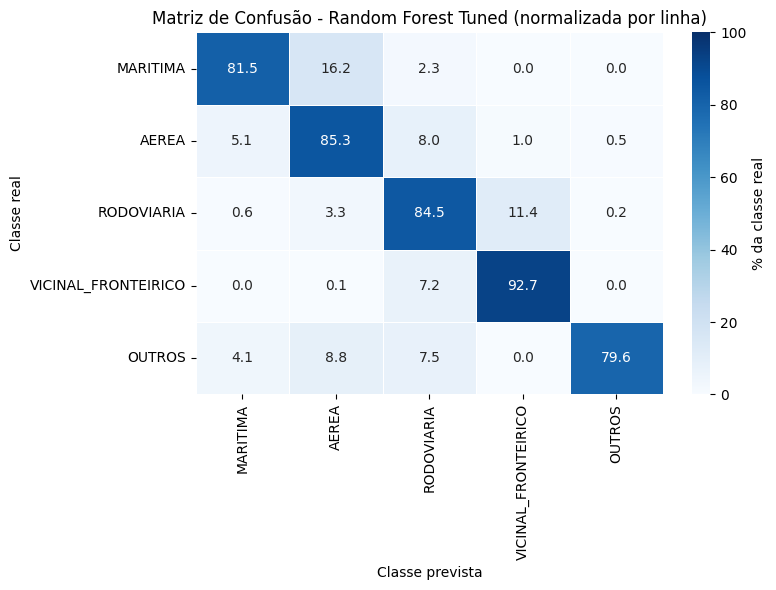

In [33]:
cm = confusion_matrix(
    y_test,
    y_pred_best_rf,
    labels=CLASS_ORDER,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm * 100,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    vmin=0,
    vmax=100,
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "% da classe real"},
    ax=ax
)

ax.set_title("Matriz de Confusão - Random Forest Tuned (normalizada por linha)")
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")

plt.tight_layout()
plt.show()

A matriz de confusão do modelo tunado mostra melhora em quase todas as classes em relação ao Random Forest sem tuning. **AEREA** e **RODOVIARIA** passam para recall acima de 0,84, a **MARITIMA** sobe para 0,81, e a classe **OUTROS**, antes a mais confundida, melhora bastante (recall 0,80).

# Importância das Variáveis
A tabela apresenta as variáveis mais relevantes para a classificação da via de transporte. Valores mais elevados indicam maior contribuição para as decisões tomadas pelo modelo.

In [34]:
feature_names = (
    best_rf
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    best_rf
    .named_steps["classifier"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
199,cat__country_code_586,0.185523
2,num__value_per_kg,0.075292
1,num__fob_value_usd,0.074611
0,num__net_weight_kg,0.062004
345,cat__ncm_chapter_71,0.057400
264,cat__country_code_845,0.044803
42,cat__country_code_63,0.042954
57,cat__country_code_97,0.040930
101,cat__country_code_249,0.021636
74,cat__country_code_158,0.018150


In [35]:
top_features = importance_df.head(15)

top_features

,feature,importance
199,cat__country_code_586,0.185523
2,num__value_per_kg,0.075292
1,num__fob_value_usd,0.074611
0,num__net_weight_kg,0.062004
345,cat__ncm_chapter_71,0.057400
264,cat__country_code_845,0.044803
42,cat__country_code_63,0.042954
57,cat__country_code_97,0.040930
101,cat__country_code_249,0.021636
74,cat__country_code_158,0.018150


Entre as 15 variáveis mais importantes, predominam países de destino (Paraguai, Uruguai, Argentina, Bolívia, Estados Unidos e Chile, que aparecem pelos códigos no gráfico) e estados de origem (PR, CE, SP), além das três variáveis numéricas (`value_per_kg`, `fob_value_usd`, `net_weight_kg`) e do capítulo NCM 71.

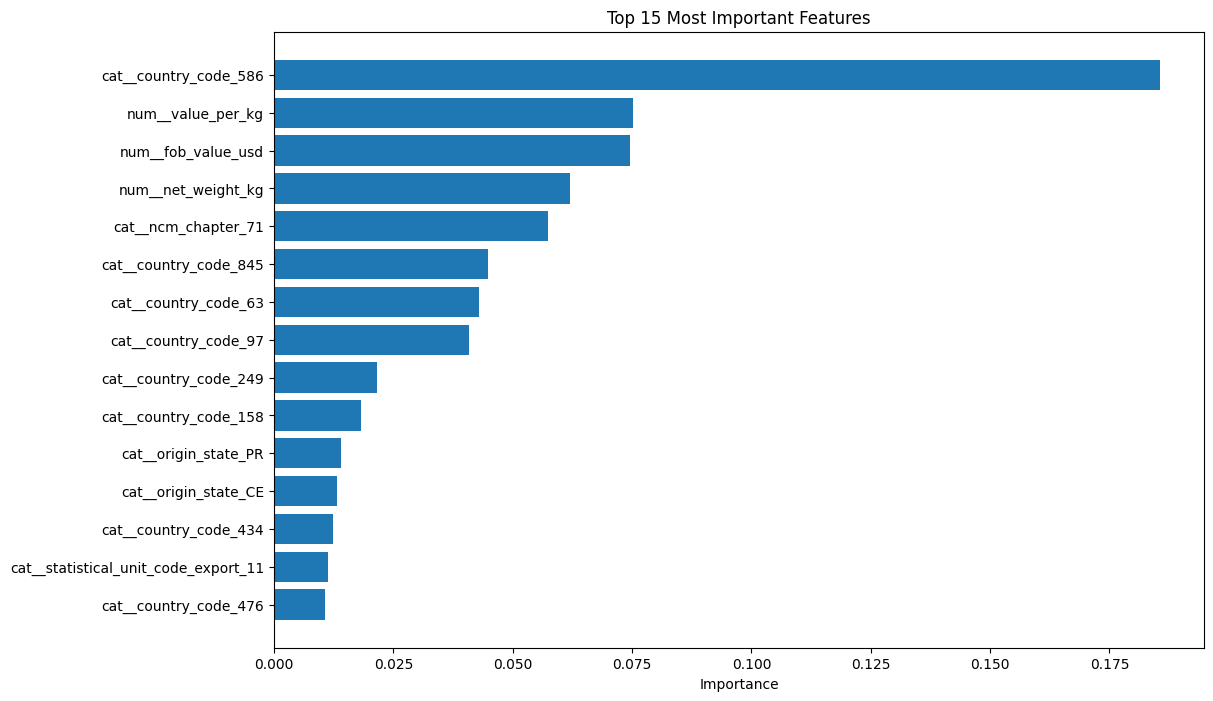

In [36]:
plt.figure(figsize=(12,8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title(
    "Top 15 Most Important Features"
)

plt.xlabel("Importance")

plt.show()

O país de destino **Paraguai** (código 586) é, isoladamente, a variável mais importante do modelo, com importância bem acima das demais (cerca de 0,19). Em seguida aparecem `value_per_kg`, `fob_value_usd` e `net_weight_kg`, mostrando que o valor e o peso da carga também pesam na decisão da via de transporte. O capítulo NCM **71** e outros países vizinhos (Uruguai, Argentina, Bolívia) completam o grupo das variáveis mais relevantes.

# Comparação Final dos Modelos

Os modelos são comparados utilizando as métricas de desempenho calculadas anteriormente. Essa análise permite avaliar o trade-off entre simplicidade, interpretabilidade e capacidade preditiva.

In [37]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest Tuned"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        best_rf_accuracy
    ],
    "F1 Macro": [
        logistic_f1_macro,
        rf_f1_macro,
        best_rf_f1_macro
    ],
    "F1 Weighted": [
        logistic_f1_weighted,
        rf_f1_weighted,
        best_rf_f1_weighted
    ]
})

results.sort_values(
    by="F1 Weighted",
    ascending=False
)

,Model,Accuracy,F1 Macro,F1 Weighted
2,Random Forest Tuned,0.831763,0.674947,0.839543
1,Random Forest,0.746486,0.536576,0.765940
0,Logistic Regression,0.725406,0.522577,0.749963


**Random Forest Tuned foi o melhor modelo deste notebook**, com Accuracy de 83,2% e F1 Weighted de 0,84, superando a Regressão Logística e o Random Forest sem ajuste. O ganho do tuning em relação ao RF original (de 0,77 para 0,84 de F1 Weighted) confirma que a otimização de hiperparâmetros funcionou de fato, encontrando uma configuração diferente e melhor que a inicial.

# Resposta - Pergunta de Pesquisa e Hipótese

## Pergunta de Pesquisa
O objetivo deste trabalho foi desenvolver um modelo capaz de prever a via de transporte utilizada em operações de exportação a partir das características da carga e da operação comercial. Os resultados demonstraram que essa previsão é possível com bom desempenho. O modelo Random Forest Tuned atingiu 83,18% de acurácia e F1 Weighted de 0,8395, indicando que as variáveis disponíveis contêm informações relevantes e suficientes para explicar grande parte da escolha do modal de transporte.

Portanto, conclui-se que características relacionadas ao produto exportado, ao valor da operação e ao contexto geográfico são capazes de explicar a maior parte da decisão logística observada nos dados históricos, sendo o ajuste de hiperparâmetros um passo importante para extrair esse desempenho do modelo.

## Hipótese
- **O peso da carga (KG_LIQUIDO) e a origem geográfica (SG_UF_NCM) influenciam mais a escolha da via de transporte do que o valor FOB.**

A hipótese proposta foi parcialmente confirmada pelos resultados obtidos. As variáveis relacionadas à localização geográfica apresentaram elevada relevância para o modelo, especialmente o país de destino (Paraguai é, isoladamente, a variável mais importante) e, em menor grau, alguns estados de origem (PR e CE).

Entretanto, o peso líquido da carga não se destacou como a variável mais importante do modelo, ficando atrás de `value_per_kg` e `fob_value_usd` em importância. Ou seja, o valor da exportação (tanto em termos absolutos quanto por quilograma) influencia mais a escolha da via de transporte do que o peso líquido isoladamente.

Dessa forma, os resultados sugerem que a escolha da via de transporte depende mais fortemente de fatores geográficos, sobretudo do país de destino, do que das características físicas da carga. A hipótese foi confirmada no que se refere à relevância da origem/destino geográfico, mas não foi confirmada em relação à predominância do peso da carga sobre o valor FOB: na prática, o valor da exportação se mostrou mais importante que o peso líquido para o modelo.